# Milestone 3

## Predictive Model Development and Optimization

### 1. Model Selection:

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("preprocessed_stroke_data.csv")

In [3]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


In [4]:
df.columns

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke', 'gender_Male', 'gender_Other', 'ever_married_Yes',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='object')

In [5]:
X = df.drop(columns=['stroke'])
y = df['stroke']

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2. Model Training:

In [7]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Update models to use class weights and SMOTE
models = {
    "Logistic Regression": make_pipeline(
        SMOTE(random_state=42),
        LogisticRegression(class_weight=class_weights_dict, max_iter=1000)
    ),
    "Random Forest": make_pipeline(
        SMOTE(random_state=42),
        RandomForestClassifier(n_estimators=200, class_weight=class_weights_dict, random_state=42)
    ),
    "Gradient Boosting": make_pipeline(
        SMOTE(random_state=42),
        GradientBoostingClassifier(n_estimators=200, random_state=42)
    ),
    "Neural Network": make_pipeline(
        SMOTE(random_state=42),
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    )
}

# Add function to find optimal threshold
def find_optimal_threshold(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    # Choose threshold that maximizes F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx]

# Train and evaluate models with optimal thresholds
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Get optimal threshold
    optimal_thresh = find_optimal_threshold(model, X_test, y_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= optimal_thresh).astype(int)
    
    print(f"{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_probs))
    print("Average Precision:", average_precision_score(y_test, y_probs))
    print("\n")

Logistic Regression
Accuracy: 0.8913894324853229
Precision: 0.25252525252525254
Recall: 0.4032258064516129
F1 Score: 0.3105590062111801
ROC AUC: 0.8444724462365591
Average Precision: 0.2344904801971278


Random Forest
Accuracy: 0.7622309197651663
Precision: 0.16104868913857678
Recall: 0.6935483870967742
F1 Score: 0.2613981762917933
ROC AUC: 0.7943632392473119
Average Precision: 0.15417636959940634


Gradient Boosting
Accuracy: 0.7847358121330724
Precision: 0.15948275862068967
Recall: 0.5967741935483871
F1 Score: 0.25170068027210885
ROC AUC: 0.782913306451613
Average Precision: 0.1443211188644669


Neural Network
Accuracy: 0.7984344422700587
Precision: 0.14705882352941177
Recall: 0.4838709677419355
F1 Score: 0.22556390977443608
ROC AUC: 0.7550235215053764
Average Precision: 0.1331229669477074




### 3. Model Evaluation: 

#### Logistic Regression

In [10]:
lr_model = models["Logistic Regression"]
lr_preds = lr_model.predict(X_test)

print("Logistic Regression")
print("Accuracy :",accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall   :", recall_score(y_test, lr_preds))
print("F1 Score :", f1_score(y_test, lr_preds))
print("ROC AUC  :", roc_auc_score(y_test, lr_preds))

Logistic Regression
Accuracy : 0.4050880626223092
Precision: 0.09253731343283582
Recall   : 1.0
F1 Score : 0.16939890710382513
ROC AUC  : 0.6833333333333333


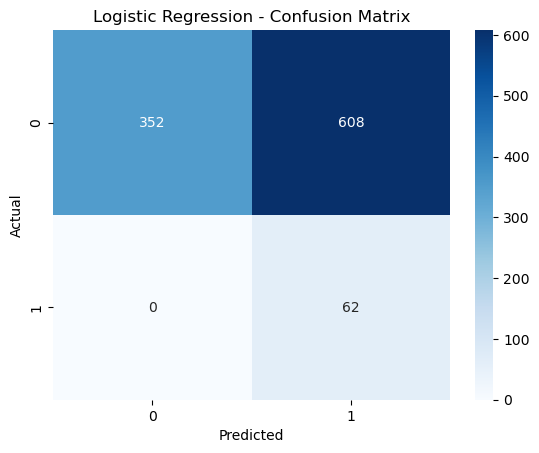

In [11]:
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Random Forest

In [12]:
rf_model = models["Random Forest"]
rf_preds = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall   :", recall_score(y_test, rf_preds))
print("F1 Score :", f1_score(y_test, rf_preds))
print("ROC AUC  :", roc_auc_score(y_test, rf_preds))

Random Forest
Accuracy : 0.9197651663405088
Precision: 0.20588235294117646
Recall   : 0.11290322580645161
F1 Score : 0.14583333333333334
ROC AUC  : 0.5423891129032258


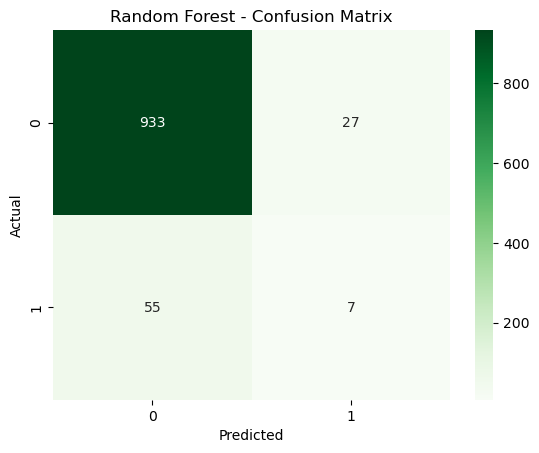

In [13]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Gradient Boosting

In [14]:
gb_model = models["Gradient Boosting"]
gb_preds = gb_model.predict(X_test)

print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, gb_preds))
print("Precision:", precision_score(y_test, gb_preds))
print("Recall   :", recall_score(y_test, gb_preds))
print("F1 Score :", f1_score(y_test, gb_preds))
print("ROC AUC  :", roc_auc_score(y_test, gb_preds))

Gradient Boosting
Accuracy : 0.8972602739726028
Precision: 0.19718309859154928
Recall   : 0.22580645161290322
F1 Score : 0.21052631578947367
ROC AUC  : 0.5832157258064516


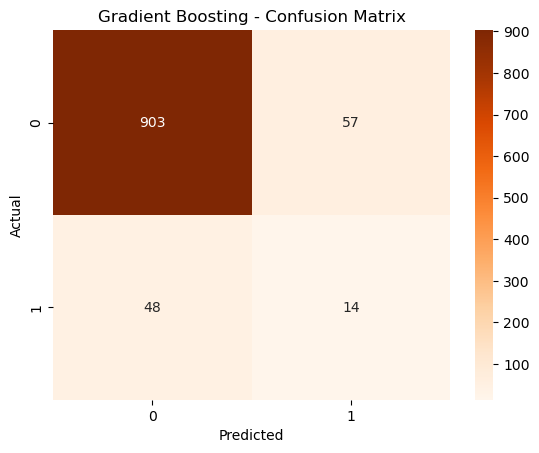

In [15]:
cm = confusion_matrix(y_test, gb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Neural Network

In [16]:
nn_model = models["Neural Network"]
nn_preds = nn_model.predict(X_test)

print("Neural Network")
print("Accuracy :", accuracy_score(y_test, nn_preds))
print("Precision:", precision_score(y_test, nn_preds))
print("Recall   :", recall_score(y_test, nn_preds))
print("F1 Score :", f1_score(y_test, nn_preds))
print("ROC AUC  :", roc_auc_score(y_test, nn_preds))

Neural Network
Accuracy : 0.8864970645792564
Precision: 0.17073170731707318
Recall   : 0.22580645161290322
F1 Score : 0.19444444444444445
ROC AUC  : 0.5774865591397851


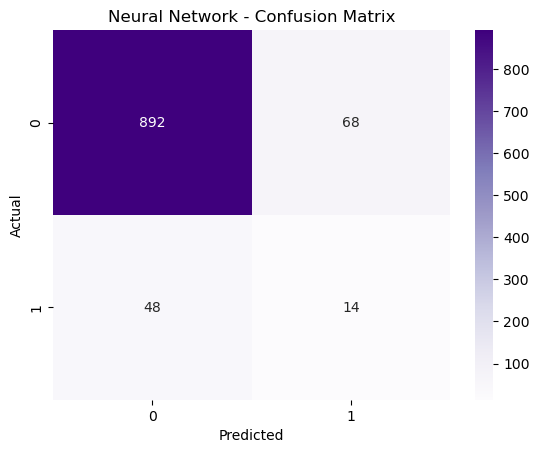

In [17]:
cm = confusion_matrix(y_test, nn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_preds),
        "Precision": precision_score(y_test, lr_preds),
        "Recall": recall_score(y_test, lr_preds),
        "F1 Score": f1_score(y_test, lr_preds),
        "ROC AUC": roc_auc_score(y_test, lr_preds)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_preds),
        "Precision": precision_score(y_test, rf_preds),
        "Recall": recall_score(y_test, rf_preds),
        "F1 Score": f1_score(y_test, rf_preds),
        "ROC AUC": roc_auc_score(y_test, rf_preds)
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": accuracy_score(y_test, gb_preds),
        "Precision": precision_score(y_test, gb_preds),
        "Recall": recall_score(y_test, gb_preds),
        "F1 Score": f1_score(y_test, gb_preds),
        "ROC AUC": roc_auc_score(y_test, gb_preds)
    },
    {
        "Model": "Neural Network",
        "Accuracy": accuracy_score(y_test, nn_preds),
        "Precision": precision_score(y_test, nn_preds),
        "Recall": recall_score(y_test, nn_preds),
        "F1 Score": f1_score(y_test, nn_preds),
        "ROC AUC": roc_auc_score(y_test, nn_preds)
    }
]

In [19]:
final_result = pd.DataFrame(results)
final_result.set_index("Model", inplace=True)
final_result

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.405088,0.092537,1.000000,0.169399,0.683333
Random Forest,0.919765,0.205882,0.112903,0.145833,0.542389
Gradient Boosting,0.897260,0.197183,0.225806,0.210526,0.583216
Neural Network,0.886497,0.170732,0.225806,0.194444,0.577487


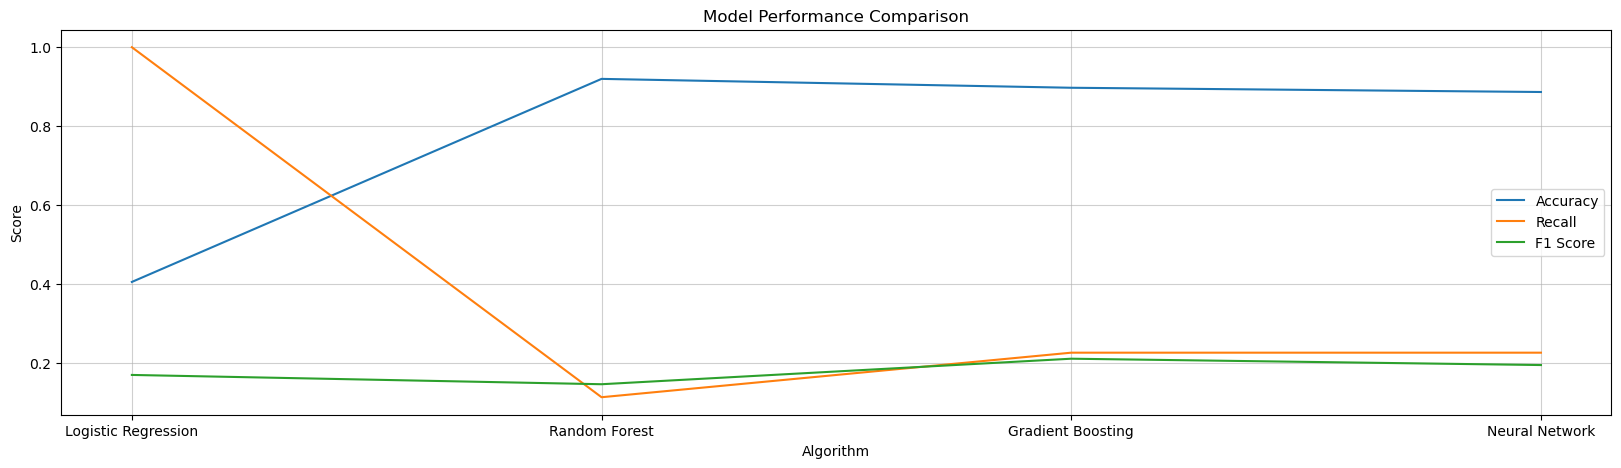

In [20]:
models = final_result.index
accuracy = final_result['Accuracy']
recall = final_result['Recall']
f1_score = final_result['F1 Score']

fig, ax = plt.subplots(figsize=(20, 5))
plt.plot(models, accuracy, label='Accuracy')
plt.plot(models, recall, label='Recall')
plt.plot(models, f1_score, label='F1 Score')

plt.title('Model Performance Comparison')
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.6)

plt.show()

### 4. Model Optimization:

In [21]:
rf = RandomForestClassifier(random_state=42)

random_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30]
}

rf_random_search = RandomizedSearchCV(estimator=rf,
                                      param_distributions=random_grid,
                                      n_iter=30,
                                      cv=5,
                                      random_state=42,
                                      scoring='f1')

rf_random_search.fit(X_train, y_train)

print("Best parameters from Random Search:")
print(rf_random_search.best_params_)


Best parameters from Random Search:
{'n_estimators': 100, 'max_depth': None}


In [22]:
param_grid = {
    'n_estimators': [rf_random_search.best_params_['n_estimators']],
}

# Only include max_depth in param_grid if it's not None in best_params_
if rf_random_search.best_params_['max_depth'] is not None:
    param_grid['max_depth'] = [
        rf_random_search.best_params_['max_depth'] - 5,
        rf_random_search.best_params_['max_depth']
    ]
else:
    # You might want to specify some reasonable range if best was None
    param_grid['max_depth'] = [5, 10, None]  # Example values

rf_grid_search = GridSearchCV(estimator=rf,
                            param_grid=param_grid,
                            cv=5,
                            scoring='f1')

rf_grid_search.fit(X_train, y_train)
best_model = rf_grid_search.best_estimator_

print("Best parameters from Grid Search:")
print(rf_grid_search.best_params_)

y_pred = rf_grid_search.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best parameters from Grid Search:
{'max_depth': None, 'n_estimators': 100}
Confusion Matrix:
 [[960   0]
 [ 62   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [23]:
import pickle

In [24]:
pickle.dump(best_model, open('stroke_model.pkl', 'wb'))

In [25]:
# Save the feature columns used during training
columns = X.columns
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(columns, f)


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pickle.dump(scaler, open('scaler.pkl', 'wb'))  # Save it